# Principal Components Analysis

by *Steve Pittard (references provided along the way) wsp@emory.edu*

Principal Component Analysis (PCA) is a technique for simplifying complex datasets by transforming the original variables into a smaller set of new variables called principal components. Each component is a linear recombination of the original features, constructed to capture as much variation in the data as possible. 

The first component explains the most variance, the second explains the next most, and so on. Rather than selecting a subset of existing variables, PCA creates new axes that summarize the underlying structure of the data, often allowing us to represent it in far fewer dimensions while retaining most of the information.

PCA is particularly useful when the original features are highly correlated or when the dataset contains many variables. In these situations, much of the information is redundant, as multiple variables may be measuring similar underlying patterns. By examining the loadings of each variable within the components, we can begin to identify which variables are contributing the most and which tend to move together. 

## The Wisconson Breast Cancer Dataset

This is similar in spirit to how we used coefficient magnitude in logistic regression or variable importance in tree-based models to assess influence, although PCA is not using the outcome variable (e.g. diabetes in the Pima data) and instead reflects the structure of the predictors themselves. As the number of predictors grows, this type of compression becomes even more valuable, reducing complexity while preserving the dominant structure in the data.

In favorable cases, PCA can compress the data into a small number of components, simplifying downstream modeling. Each principal component is a linear recombination of the original features, with loadings that quantify the contribution of each variable. These loadings provide insight into how variables group and relate within components. The primary visualization tool for this structure is the biplot.

Let's look at some data that winds up being a good target for something like PCA. This is the [Wisoncon Breast Cancer Data Set](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) which is available direclty within scikit. Here is some information on the dataset. 

**Additional Information**

Features are computed from a digitized image of a fine needle aspirate (FNA) of a breast mass.  They describe characteristics of the cell nuclei present in the image. A few of the images can be found at http://www.cs.wisc.edu/~street/images/

Separating plane described above was obtained using Multisurface Method-Tree (MSM-T) [K. P. Bennett, "Decision Tree Construction Via Linear Programming." Proceedings of the 4th Midwest Artificial Intelligence and Cognitive Science Society, pp. 97-101, 1992], a classification method which uses linear programming to construct a decision tree.  Relevant features were selected using an exhaustive search in the space of 1-4 features and 1-3 separating planes.

The actual linear program used to obtain the separating plane in the 3-dimensional space is that described in: [K. P. Bennett and O. L. Mangasarian: "Robust Linear Programming Discrimination of Two Linearly Inseparable Sets", Optimization Methods and Software 1, 1992, 23-34].

In [8]:
from sklearn.datasets import load_breast_cancer
bcdata = load_breast_cancer()
X, y = bcdata.data, bcdata.target
print(bcdata.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [9]:
import pandas as pd

from sklearn.datasets import load_breast_cancer

# Load data
bcdata = load_breast_cancer()
X = pd.DataFrame(bcdata.data, columns=bcdata.feature_names)
y = pd.Series(bcdata.target, name="target")  # 0 = malignant, 1 = benign

print(X.shape)
print(X.head())
print("\nClass distribution:")
print(y.value_counts())

(569, 30)
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0 

# The Physicians View 

What a clinician might prioritize..


| Category              | Description |
|----------------------|-------------|
| Size (radius, area, perimeter, especially “worst”) | These are often the most immediately informative features. Larger tumors and those with larger extreme measurements (“worst” values) raise more concern for malignancy. Clinicians pay particular attention to the largest observed dimensions, as they reflect the most aggressive or developed portion of the tumor. |
| Shape (concavity, concave points) | The geometry of the tumor boundary is highly informative. Benign tumors tend to have smoother, more regular edges, while malignant tumors often show irregular, jagged contours. Measures like concavity and concave points help quantify how much the tumor deviates from a simple, rounded shape. |
| Texture (texture, especially “worst”) | Texture captures how uniform or varied the tissue appears. Malignant tumors often exhibit greater heterogeneity, meaning the internal structure looks more disorganized. Higher texture values can indicate this variability, which may signal abnormal growth. |
| Additional structure (compactness, symmetry) | These features provide supporting information about how orderly the tumor is. Lower symmetry or unusual compactness can suggest structural irregularities. While not always primary indicators on their own, they help build a more complete picture when considered alongside size and shape. |

---

So we don't have time to fully investigate all of the above variables because we are prioritizing Machine Learning concepts to help us build models although anything you might already know about Breast Cancer could help you include (or exclude) variables in this data. There might also be a specific clinical question being presented to you that might influence your descision to include/exclude (or transform) information. On the other hand, one of the benefits of NOT knowing a lot about the domain (in this case Breast Cancer Oncology) is that you can use statistically sound approaches in ML to help you identify important variables of interest as you build a model. You can then present the variables to the physician to see if that matches their hypotheses.

## Some EDA Plots

Let's fcus on the first category which us **Size**. We'll perform some basic EDA on these variables. Let's look at one plot of the radius since that is frequently identified as variable of interest by clinicians. The first is somewhat obvious in that as the mean radius increases so will the mean area. 

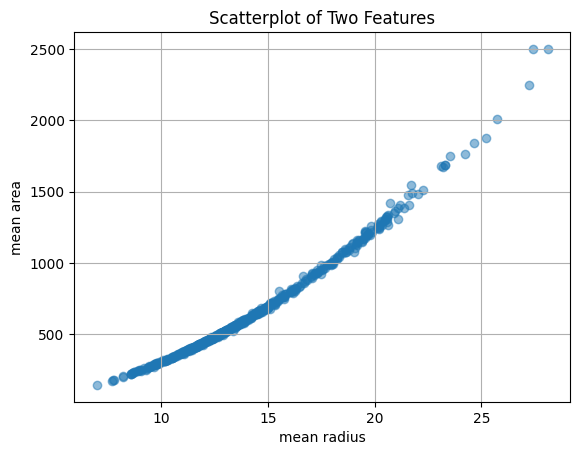

In [10]:
import matplotlib.pyplot as plt
plt.scatter(X["mean radius"], X["mean area"], alpha=0.5)
plt.xlabel("mean radius")
plt.ylabel("mean area")
plt.title("Scatterplot of Two Features")
plt.grid()
plt.show()

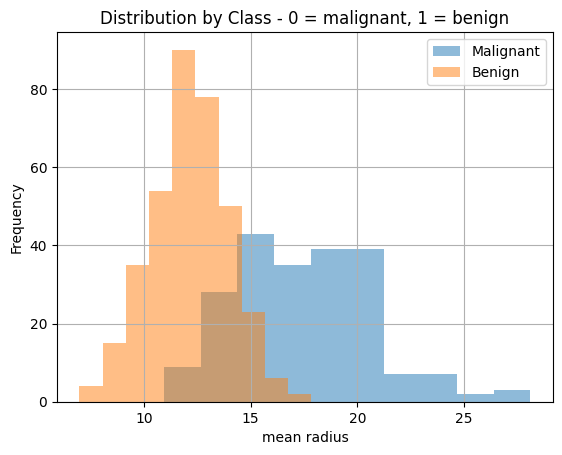

In [85]:
plt.hist(X[y == 0]["mean radius"], alpha=0.5, label="Malignant")
plt.hist(X[y == 1]["mean radius"], alpha=0.5, label="Benign")

plt.xlabel("mean radius")
plt.ylabel("Frequency")
plt.title("Distribution by Class - 0 = malignant, 1 = benign")
plt.legend()
plt.grid()
plt.show()

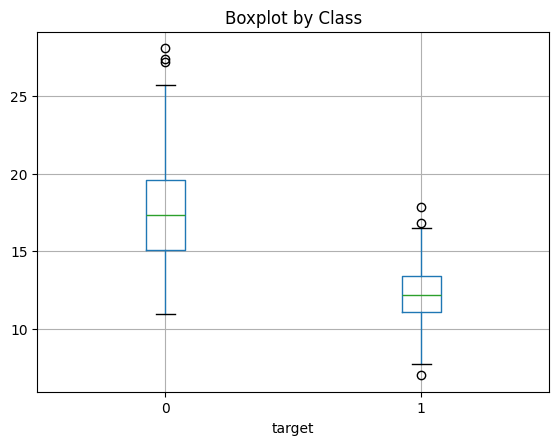

In [11]:
import pandas as pd

df = X.copy()      # Makes a separate copy of X
df["target"] = y

df.boxplot(column="mean radius", by="target")
plt.title("Boxplot by Class")
plt.suptitle("")
plt.show()

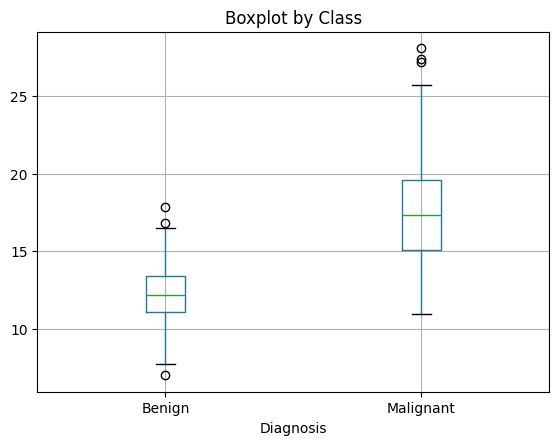

In [35]:
df["target"] = y

# Map numeric labels to meaningful names
df["target"] = df["target"].map({
    0: "Malignant",
    1: "Benign"
})

df.boxplot(column="mean radius", by="target")

plt.title("Boxplot by Class")
plt.suptitle("")
plt.xlabel("Diagnosis")
plt.show()

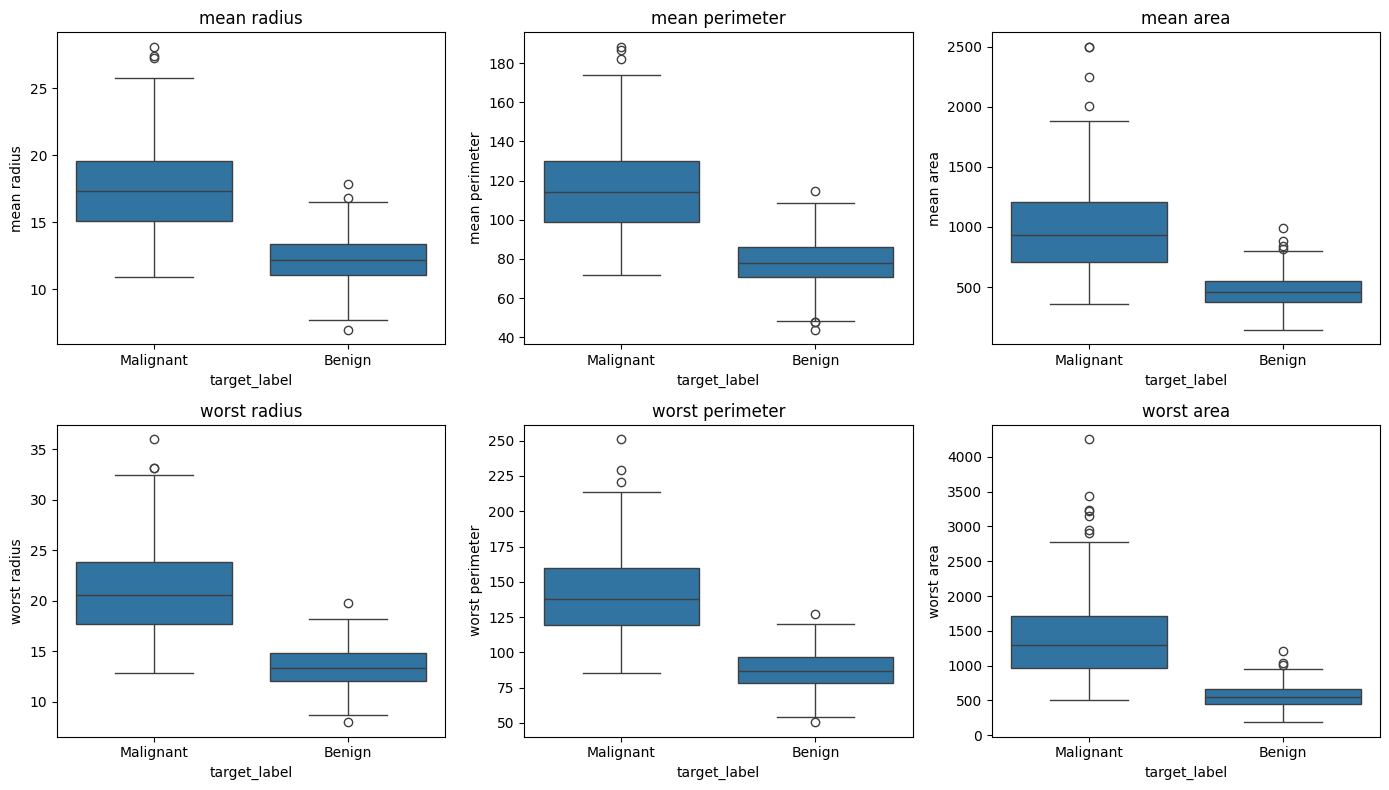

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine X and y for plotting
df = X.copy()
df["target"] = y  # assume 0 = malignant, 1 = benign

# Map labels for readability
df["target_label"] = df["target"].map({0: "Malignant", 1: "Benign"})

# Size-related features
size_features = [
    "mean radius", "mean perimeter", "mean area",
    "worst radius", "worst perimeter", "worst area"
]

# Plot
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(size_features):
    sns.boxplot(data=df, x="target_label", y=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

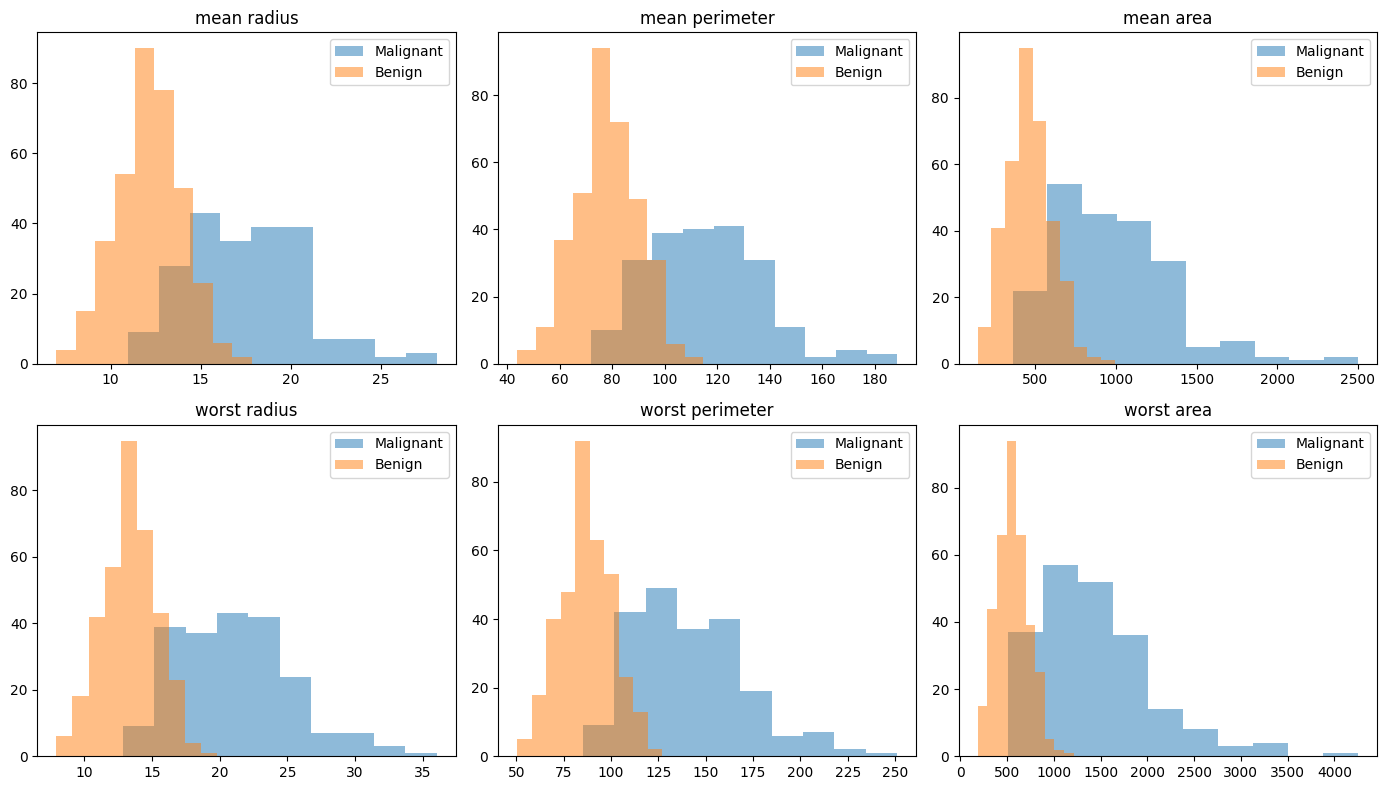

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(size_features):
    axes[i].hist(df[df["target"] == 0][col], alpha=0.5, label="Malignant")
    axes[i].hist(df[df["target"] == 1][col], alpha=0.5, label="Benign")
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.show()

## Scaled Features 

What we’re looking at in this next plot are multiple features, all scaled to the same range, across the first 20 observations. You can see that some of these features move up and down together, while others don’t. There are patterns in here — but they’re hard to isolate.

There is structure in the data and some features appear to move together... But there are too many dimensions to reason about directly. Even after scaling, we still have 30 variables. That’s simply too much to visualize or reason about at once. This is a case where the data may contain useful structure, but it’s buried in complexity or so it would seem.

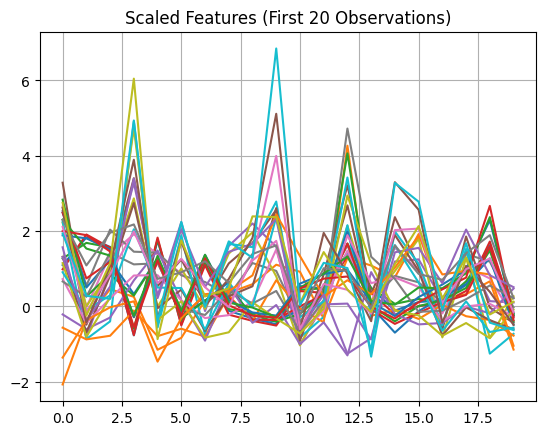

In [38]:
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)

plt.plot(X_scaled[:20])
plt.title("Scaled Features (First 20 Observations)")
plt.grid()
plt.show()

## t-SNE 

t-SNE (t-Distributed Stochastic Neighbor Embedding) is a nonlinear dimensionality reduction technique primarily used for visualization. Unlike methods such as PCA, which focus on preserving overall variance and global structure, t-SNE emphasizes preserving local relationships between observations. 

This makes it especially useful during exploratory data analysis, where we want to see whether natural groupings or clusters exist in the data. It is important to note that while clusters in a t-SNE plot can be meaningful, the overall shape and distances between clusters are not necessarily interpretable.

This plot isn't to show specific features or how the relate but to show how the data might cluster into groups. Here we have a clear case of patients separating into two groups - those with cancer and those without. 

In this case using t-SNE might be overkill because there could in fact be sub clusters that might help us. 

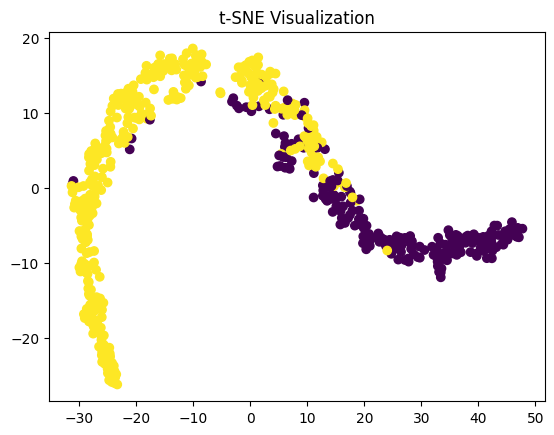

In [39]:
from sklearn.manifold import TSNE

X_tsne = TSNE(n_components=2, random_state=42).fit_transform(X)

plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y)
plt.title("t-SNE Visualization")
plt.show()

## Correlations 

Correlation measures the extent to which two variables move together, providing a simple way to identify relationships among predictors. In datasets like this one, many of the features are highly correlated because they are capturing similar underlying properties, such as tumor size or shape. For example, variables like radius, perimeter, and area tend to increase together, reflecting the same general concept from slightly different perspectives. 

While this redundancy is not necessarily problematic, it does mean that we are carrying more variables than we may need. When many features contain overlapping information, it becomes harder to interpret models and visualize structure. This makes the dataset a strong candidate for dimensionality reduction, where techniques like PCA can combine correlated variables into a smaller set of components that retain most of the original information.

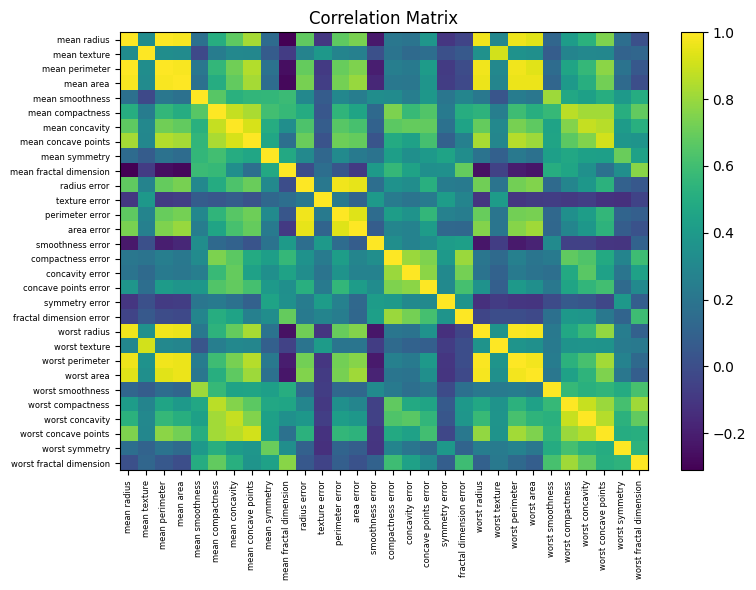

In [40]:
import matplotlib.pyplot as plt

corr = X.corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.title("Correlation Matrix")
plt.xticks(range(len(X.columns)), X.columns, rotation=90, fontsize=6)
plt.yticks(range(len(X.columns)), X.columns, fontsize=6)
plt.tight_layout()
plt.show()

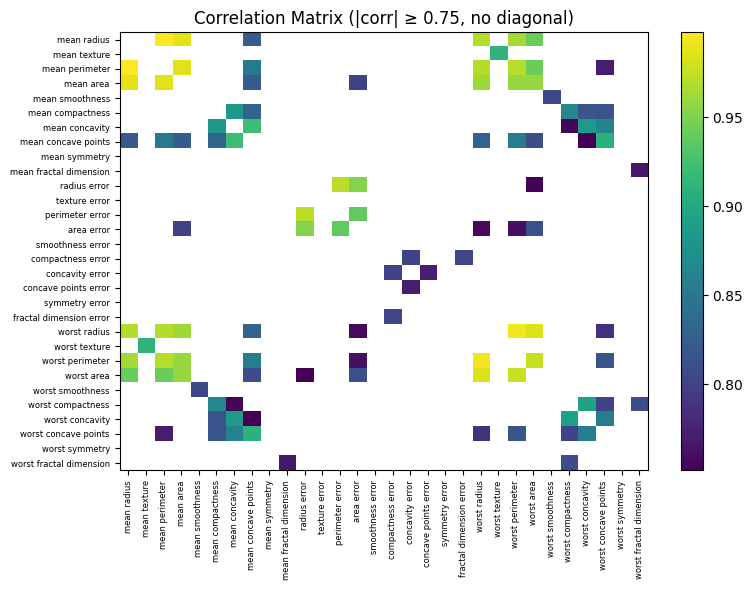

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Correlation matrix
corr = X.corr()

# Make a true writable NumPy copy
corr_plot = corr.to_numpy(copy=True)

# Remove diagonal
np.fill_diagonal(corr_plot, np.nan)

# Keep only strong correlations
corr_plot[np.abs(corr_plot) < 0.75] = np.nan

# Plot
plt.figure(figsize=(8, 6))
plt.imshow(corr_plot, aspect='auto')
plt.colorbar()
plt.title("Correlation Matrix (|corr| ≥ 0.75, no diagonal)")

plt.xticks(range(len(X.columns)), X.columns, rotation=90, fontsize=6)
plt.yticks(range(len(X.columns)), X.columns, fontsize=6)


plt.tight_layout()
plt.show()

## Onto PCA

The correlation matrix makes it clear that many of these variables are strongly related, with several features moving together in tightly connected groups. While this confirms that the data contains meaningful structure, it also highlights a challenge: much of the information is redundant, making it difficult to interpret and visualize the dataset in its current form. Rather than working with many overlapping variables, we can look for a smaller set of features that capture these shared patterns. 

This is where PCA becomes useful, as it combines correlated variables into a reduced set of components that retain most of the variation in the data. Before applying PCA, however, we first *scale the data** so that all variables are placed on a comparable footing. Since PCA is driven by variance, features measured on larger scales would otherwise dominate the results, making scaling an essential first step.

In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)

[[ 1.09706398 -2.07333501  1.26993369 ...  2.29607613  2.75062224
   1.93701461]
 [ 1.82982061 -0.35363241  1.68595471 ...  1.0870843  -0.24388967
   0.28118999]
 [ 1.57988811  0.45618695  1.56650313 ...  1.95500035  1.152255
   0.20139121]
 ...
 [ 0.70228425  2.0455738   0.67267578 ...  0.41406869 -1.10454895
  -0.31840916]
 [ 1.83834103  2.33645719  1.98252415 ...  2.28998549  1.91908301
   2.21963528]
 [-1.80840125  1.22179204 -1.81438851 ... -1.74506282 -0.04813821
  -0.75120669]]


### Doing The PCA

This is amazingly easy to do with scikit. It's actually easy to do but a bit harder to understand what is actually happening in terms of what you get back. That said, our goal is replace, in this case, the 30 columns (each of which represents a dimension) with a much lower number of columns - in this case the Principal Components. The idea here is that each component represents a certain amount of variation in the data set say, for exampl3, 44 percent. And perhaps the second component represents 18 percent and so on. If we can capture say 90% of the variation with say 5 components then we can use that data to train on rather than the original data set with its 30 columns.

> ⚠️ **Caveat:** PCA replaces the original variables with linear combinations of them. While this can simplify modeling, it reduces direct interpretability. The original data is always retained, and the transformation can be inverted only if all components are kept.

Although PCA allows us to reduce the dataset from many variables down to just a few components, it’s important to remember that these components are not original features. Each principal component is a linear combination of all the original variables, meaning our models are built on transformed versions of the data rather than the raw measurements themselves. This is often perfectly acceptable, especially when the goal is prediction or dimensionality reduction, but it does come at the cost of direct interpretability. In principle, we can map back to the original feature space using an inverse transformation, but this reconstruction is only exact if we retain all components. When we keep only a subset, we are working with an approximation.

In practice, tools like scikit-learn’s Pipeline make this process much cleaner by encapsulating scaling, PCA, and modeling into a single, reproducible workflow. The transformations are applied consistently during both training and prediction, without requiring us to manually manage each step. Importantly, the original data remains unchanged and available, so PCA serves as an additional representation rather than a replacement.


In [43]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained = pd.Series(
    pca.explained_variance_ratio_,
    index=[f"PC{i+1}" for i in range(X.shape[1])]
)

print("Explained variance:")
print(explained.head())

print("\nCumulative variance:")
print(explained.cumsum().head(10))

Explained variance:
PC1    0.442720
PC2    0.189712
PC3    0.093932
PC4    0.066021
PC5    0.054958
dtype: float64

Cumulative variance:
PC1     0.442720
PC2     0.632432
PC3     0.726364
PC4     0.792385
PC5     0.847343
PC6     0.887588
PC7     0.910095
PC8     0.925983
PC9     0.939879
PC10    0.951569
dtype: float64


What the above means is that by the time we include PC1, PC2, ... PC5 we have captured 84 percent of the total variation in the dataset so we could just choose to work those. This would be easier than working with the 30 columns (dimensions) we started with. Note the following characteristics

In [44]:
print("There are",len(pca.explained_variance_ratio_),"principal components though not all of them capture a lot of variation")

There are 30 principal components though not all of them capture a lot of variation


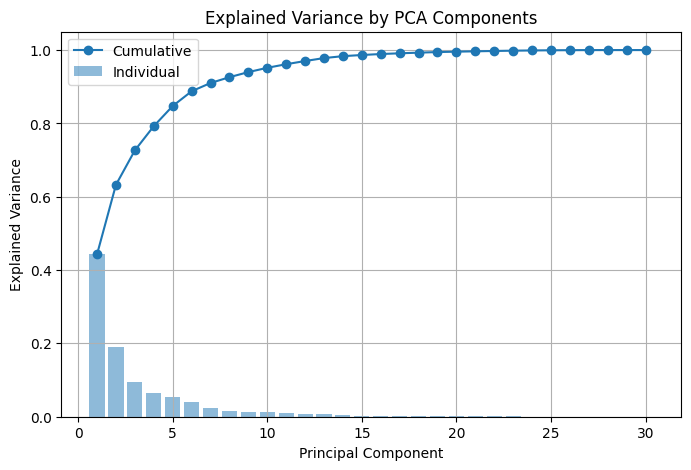

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Individual explained variance
explained_vals = pca.explained_variance_ratio_

# Cumulative variance
cumulative_vals = np.cumsum(explained_vals)

# Plot
plt.figure(figsize=(8,5))

# Bar plot (individual components)
plt.bar(range(1, len(explained_vals)+1), explained_vals, alpha=0.5, label="Individual")

# Line plot (cumulative)
plt.plot(range(1, len(cumulative_vals)+1), cumulative_vals, marker='o', label="Cumulative")

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance")
plt.title("Explained Variance by PCA Components")
plt.legend()
plt.grid()
plt.show()

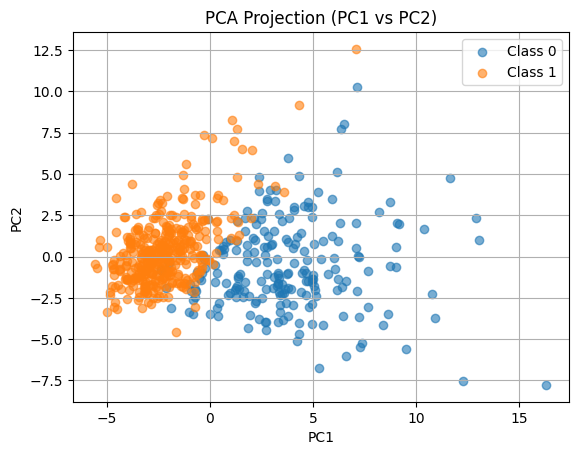

In [46]:
pca_df = pd.DataFrame(X_pca[:, :2], columns=["PC1", "PC2"])
pca_df["target"] = y.values

plt.figure()

for label, subset in pca_df.groupby("target"):
    plt.scatter(subset["PC1"], subset["PC2"], label=f"Class {label}", alpha=0.6)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (PC1 vs PC2)")
plt.legend()
plt.grid()
plt.show()

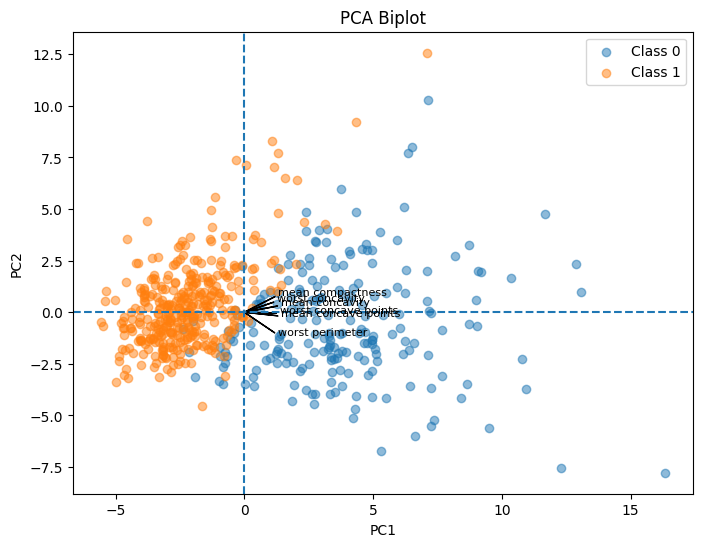

In [47]:
import numpy as np


loadings = pca.components_.T[:, :2]

# pick top 6 variables contributing to PC1
top_vars = np.argsort(np.abs(loadings[:, 0]))[::-1][:6]


plt.figure(figsize=(8,6))

# scatter
for label, subset in pca_df.groupby("target"):
    plt.scatter(subset["PC1"], subset["PC2"], alpha=0.5, label=f"Class {label}")

# arrows
scale = 5
for i in top_vars:
    plt.arrow(0, 0,
              loadings[i,0]*scale,
              loadings[i,1]*scale,
              color='black')
    plt.text(loadings[i,0]*scale*1.1,
             loadings[i,1]*scale*1.1,
             X.columns[i],
             fontsize=8)

plt.axhline(0, linestyle='--')
plt.axvline(0, linestyle='--')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Biplot")
plt.legend()
plt.show()

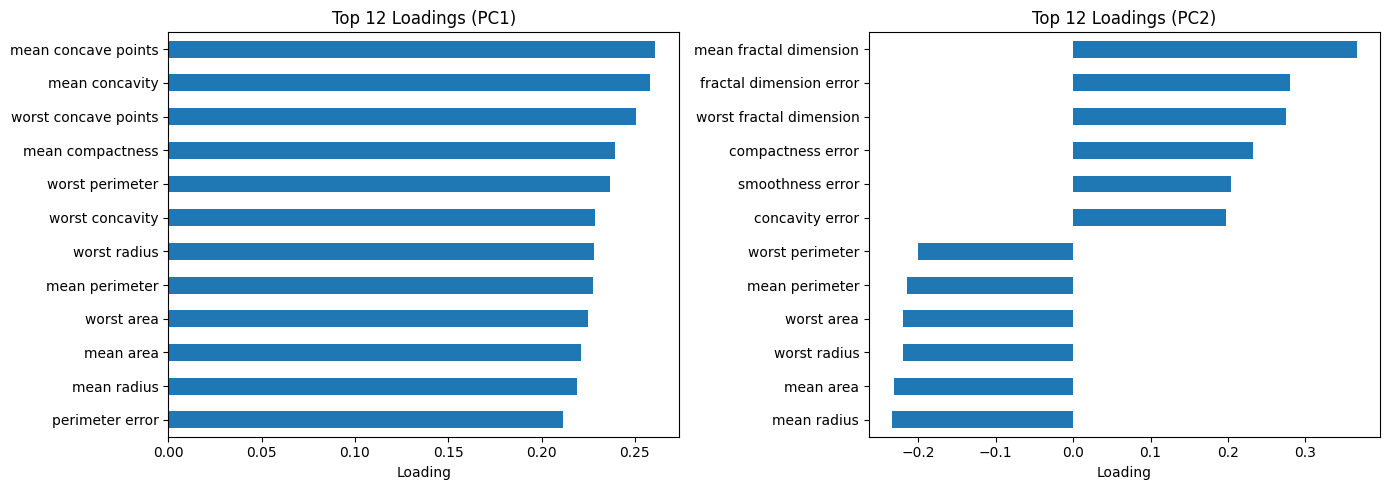

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# Create loading Series
pc1 = pd.Series(pca.components_[0], index=X.columns)
pc2 = pd.Series(pca.components_[1], index=X.columns)

# Select top 12 by magnitude (keep sign)
pc1_top = pc1.reindex(pc1.abs().sort_values(ascending=False).index[:12])
pc2_top = pc2.reindex(pc2.abs().sort_values(ascending=False).index[:12])

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14,5))

pc1_top.sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Top 12 Loadings (PC1)")
axes[0].set_xlabel("Loading")

pc2_top.sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Top 12 Loadings (PC2)")
axes[1].set_xlabel("Loading")

plt.tight_layout()
plt.show()

So let's build some models. First, we'll create a model on the scaled data but will not use the PCA-compressed data. This will allow us to do some comparisons between the two. We've seen how to do this before so there should be no surprises.

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Full model
pipe_full = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000)
)

pipe_full.fit(X_train, y_train)
pred_full = pipe_full.predict(X_test)



# Results
print("Full Model Performance on Test Data:\n")
print(classification_report(y_test, pred_full))


Full Model Performance on Test Data:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [50]:
# PCA model
pipe_pca = make_pipeline(
    StandardScaler(),
    PCA(n_components=5),
    LogisticRegression(max_iter=5000)
)

pipe_pca.fit(X_train, y_train)
pred_pca = pipe_pca.predict(X_test)

print("\nPCA Model Performance on Test Data:\n")
print(classification_report(y_test, pred_pca))


PCA Model Performance on Test Data:

              precision    recall  f1-score   support

           0       0.93      0.95      0.94        42
           1       0.97      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [51]:
import pandas as pd
from sklearn.metrics import classification_report

# Convert reports to dictionaries
report_full = classification_report(y_test, pred_full, output_dict=True)
report_pca  = classification_report(y_test, pred_pca, output_dict=True)

# Convert to DataFrames
df_full = pd.DataFrame(report_full).T
df_pca  = pd.DataFrame(report_pca).T

# Add model labels
df_full["Model"] = "Full"
df_pca["Model"]  = "PCA (5)"

# Combine
df_compare = pd.concat([df_full, df_pca])

print(df_compare)

              precision    recall  f1-score     support    Model
0              0.976190  0.976190  0.976190   42.000000     Full
1              0.986111  0.986111  0.986111   72.000000     Full
accuracy       0.982456  0.982456  0.982456    0.982456     Full
macro avg      0.981151  0.981151  0.981151  114.000000     Full
weighted avg   0.982456  0.982456  0.982456  114.000000     Full
0              0.930233  0.952381  0.941176   42.000000  PCA (5)
1              0.971831  0.958333  0.965035   72.000000  PCA (5)
accuracy       0.956140  0.956140  0.956140    0.956140  PCA (5)
macro avg      0.951032  0.955357  0.953106  114.000000  PCA (5)
weighted avg   0.956505  0.956140  0.956245  114.000000  PCA (5)


In [52]:
loadings_df = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(X.shape[1])]
)

print(loadings_df["PC1"].sort_values(key=abs, ascending=False).head(10))

mean concave points     0.260854
mean concavity          0.258400
worst concave points    0.250886
mean compactness        0.239285
worst perimeter         0.236640
worst concavity         0.228768
worst radius            0.227997
mean perimeter          0.227537
worst area              0.224871
mean area               0.220995
Name: PC1, dtype: float64


In [53]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Build pipeline
pipe = make_pipeline(
    StandardScaler(),
    PCA(n_components=5),
    LogisticRegression(max_iter=5000)
)

# Fit
pipe.fit(X_train, y_train)

# Predict
pred = pipe.predict(X_test)

# Evaluate
print("PCA Pipeline Performance:\n")
print(classification_report(y_test, pred))

PCA Pipeline Performance:

              precision    recall  f1-score   support

           0       0.93      0.95      0.94        42
           1       0.97      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [54]:
from sklearn.model_selection import cross_validate

# Define scoring metrics
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "roc_auc": "roc_auc"
}

# Run cross-validation
cv_results = cross_validate(
    pipe,
    X, y,
    cv=5,
    scoring=scoring,
    return_train_score=False
)

# Convert to DataFrame
import pandas as pd
cv_df = pd.DataFrame(cv_results)

print(cv_df)

   fit_time  score_time  test_accuracy  test_precision  test_recall  \
0  0.008585    0.005549       0.956140        0.958333     0.971831   
1  0.004722    0.006306       0.964912        0.971831     0.971831   
2  0.003759    0.005364       0.964912        0.972222     0.972222   
3  0.003979    0.004293       0.973684        0.972603     0.986111   
4  0.002916    0.004270       0.991150        1.000000     0.985915   

   test_roc_auc  
0      0.995414  
1      0.995087  
2      0.995040  
3      0.986442  
4      0.999665  


<Axes: >

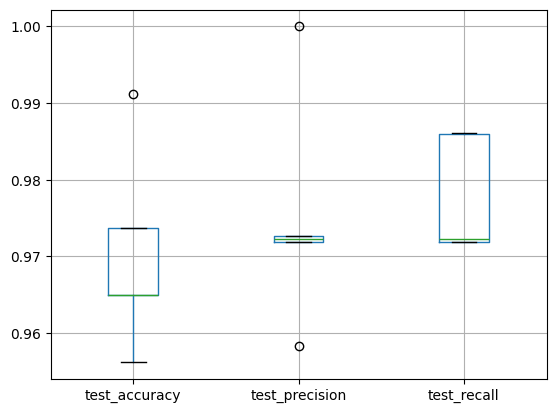

In [55]:
cv_df.boxplot(['test_accuracy','test_precision','test_recall'])

# Helpful References

https://github.com/LeanKishan/breast_cancer_analysis/blob/main/analysis_extended.py
https://statisticsglobe.com/biplot-pca-python#2-biplot-of-pca-using-seaborn
https://colab.research.google.com/github/erdogant/pca/blob/master/notebooks/pca_examples.ipynb
